<div style="border: 5px solid black; padding: 10px;">

## **Name: Timothy Hollis** 
## **Course: DSC540 – Data Preparation**  
## **Date: 03/03/2026**
## **Milestone 5 – Merging the Data and Storing in a Database/Visualizing Data**  
## **Project Topic:** *Transportation Access, Living Costs, and Quality of Life Across U.S. Cities*

---

## **Notebook Overview**

This notebook integrates the three datasets developed across Milestones 2–4:

- **HUD Fair Market Rent (FMR)** – county‑level housing cost indicators  
- **Walk Score City Metrics** – walkability, transit access, and bikeability  
- **Census ACS Demographics** – population, income, commute time, poverty rate, and age  

This milestone will:

- Reproduce all cleaning steps from earlier milestones  
- Load all three cleaned datasets into a **SQLite database**  
- Perform **SQL joins** to create a unified dataset  
- Generate **six visualizations**, including:
    - Two from individual datasets
    - Two from multiple datasets
    - Twp from all datasets
- Provide a **250–500‑word summary** reflecting learning, ethics, and assumptions
</div>

## **Initial Setup:**

In [205]:
# Load Libraries
import pandas as pd
import numpy as np
import requests
import sqlite3
from io import StringIO
from IPython.display import Image, display

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:,.1f}'.format)

# Matplotlib Formatting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

# Color-blind Safe Palette
custom_palette = ['#4169E1', '#6A0DAD', '#2E8B57']
sns.set_palette(custom_palette)

print('✅ Imports and global formatting complete.')

✅ Imports and global formatting complete.


## **Load HUD Fair Market Rent (FMR) Dataset**

In [206]:
# Load HUD FMR dataset
hud_path = 'hud_fmr_raw.csv'
hud_raw = pd.read_csv(hud_path)

print('HUD dataset loaded successfully. ✅')
display(hud_raw.head())

HUD dataset loaded successfully. ✅


,stusps,state,hud_area_code,countyname,county_town_name,metro,hud_area_name,fips,pop2020,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4
0,AL,1,METRO33860M33860,Autauga County,NaN,1,"Montgomery, AL MSA",100199999,55639,836,913,1092,1383,1753
1,AL,1,METRO19300M19300,Baldwin County,NaN,1,"Daphne-Fairhope-Foley, AL MSA",100399999,218289,1051,1056,1362,1670,2114
2,AL,1,NCNTY01005N01005,Barbour County,NaN,0,"Barbour County, AL",100599999,25026,652,656,857,1089,1141
3,AL,1,METRO13820M13820,Bibb County,NaN,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100799999,22374,983,1109,1245,1570,1752
4,AL,1,METRO13820M13820,Blount County,NaN,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100999999,57755,983,1109,1245,1570,1752


## **Clean HUD Fair Market Rent (FMR) Dataset**
This section reproduces the full Milestone 2 cleaning workflow:

1. Standardize column headers  
2. Normalize county and state names  
3. Remove duplicate rows  
4. Convert rent columns to numeric  
5. Identify outliers in 2‑bedroom FMR values  

The cleaned dataset will be stored as `hud_clean`.

In [207]:
# 1. Standardize column headers
hud = hud_raw.copy()

old_cols = hud.columns.tolist()

hud.columns = (
    hud.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

new_cols = hud.columns.tolist()
header_changes = sum([1 for old, new in zip(old_cols, new_cols) if old != new])

print(f'Column headers standardized. {header_changes} headers updated. 🧹')

# 2. Normalize county and state names
hud['countyname'] = hud['countyname'].astype(str).str.title()
hud['state'] = hud['stusps'].astype(str).str.upper()

county_changes = (hud_raw['countyname'].astype(
    str).str.title() != hud['countyname']).sum()
state_changes = (hud_raw['stusps'].astype(
    str).str.upper() != hud['state']).sum()

print(f'County name normalization complete. {county_changes} changes. 🧹')
print(f'State abbreviation normalization complete. {state_changes} changes. 🧹')

# 3. Remove Duplicate Rows
duplicate_count = hud.duplicated().sum()
hud = hud.drop_duplicates()

print(f'Removed {duplicate_count} duplicate rows. 🗑️')

# 4. Convert Rent Columns to Numeric
rent_cols = [col for col in hud.columns if col.startswith('fmr_')]
conversion_count = 0

for col in rent_cols:
    before = hud[col].copy()
    hud[col] = (
        hud[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .astype(float)
    )
    conversion_count += (before != hud[col]).sum()

print(
    f'Converted rent columns to numeric. {conversion_count} values updated. 💲➡️🔢')

# 5. Identify Outliers in 2-Bedroom FMR
q1 = hud['fmr_2'].quantile(0.25)
q3 = hud['fmr_2'].quantile(0.75)
iqr = q3 - q1

lower_outlier = q1 - 1.5 * iqr
upper_outlier = q3 + 1.5 * iqr

outliers = hud[(hud['fmr_2'] < lower_outlier) | (hud['fmr_2'] > upper_outlier)]
outlier_count = len(outliers)

print(f'Identified {outlier_count} outliers in 2-bedroom FMR values. 🔍')


# Preview ckean dataset-
hud_clean = hud.copy()

print('HUD cleaning complete. 🧹✅')
display(hud_clean.head())

Column headers standardized. 0 headers updated. 🧹
County name normalization complete. 0 changes. 🧹
State abbreviation normalization complete. 0 changes. 🧹
Removed 0 duplicate rows. 🗑️
Converted rent columns to numeric. 0 values updated. 💲➡️🔢
Identified 213 outliers in 2-bedroom FMR values. 🔍
HUD cleaning complete. 🧹✅


,stusps,state,hud_area_code,countyname,county_town_name,metro,hud_area_name,fips,pop2020,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4
0,AL,AL,METRO33860M33860,Autauga County,NaN,1,"Montgomery, AL MSA",100199999,55639,836.0,913.0,"1,092.0","1,383.0","1,753.0"
1,AL,AL,METRO19300M19300,Baldwin County,NaN,1,"Daphne-Fairhope-Foley, AL MSA",100399999,218289,"1,051.0","1,056.0","1,362.0","1,670.0","2,114.0"
2,AL,AL,NCNTY01005N01005,Barbour County,NaN,0,"Barbour County, AL",100599999,25026,652.0,656.0,857.0,"1,089.0","1,141.0"
3,AL,AL,METRO13820M13820,Bibb County,NaN,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100799999,22374,983.0,"1,109.0","1,245.0","1,570.0","1,752.0"
4,AL,AL,METRO13820M13820,Blount County,NaN,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100999999,57755,983.0,"1,109.0","1,245.0","1,570.0","1,752.0"


<div style="border: 5px solid black; padding: 10px;">

### **HUD Cleaning Summary 🧹**

The HUD Fair Market Rent dataset required minimal cleaning because the official HUD flat file is already standardized. The following updates were applied:

- **0 column headers** required renaming  
- **0 county names** required normalization  
- **0 state abbreviations** required normalization  
- **0 duplicate rows** were removed  
- **0 rent values** required conversion adjustments  
- **213 outliers** were identified in 2‑bedroom FMR values using the IQR method  

The cleaned dataset (`hud_clean`) is now ready for integration into the SQLite database and subsequent joins.

## **Scrape and Clean Walk Score City Rankings**

This section reproduces the Milestone 3 workflow by scraping the Walk Score city rankings table directly from:

**https://www.walkscore.com/cities-and-neighborhoods/**

And completes the following steps to clean the dataset:

1. Standardize column headers  
2. Fix UTF‑8 encoding issues in city names  
3. Convert scores and population to numeric  
4. Add country column and clean state codes  
5. Flag rows with missing scores  
6. Remove duplicates and sort by Walk Score  

The cleaned dataset will be stored as `walk_clean`.

---

In [208]:
# Scrape Site:

walk_url = 'https://www.walkscore.com/cities-and-neighborhoods/'

print('Requesting Walk Score city rankings... 🌐🔍')

tables = pd.read_html(walk_url)
walk_raw = tables[0]  # first table on the page

print('Walk Score table scraped successfully. ✅')
display(walk_raw.head())

walk = walk_raw.copy()

# 1. Standardize column headers
old_cols = walk.columns.tolist()
walk.columns = (
    walk.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
new_cols = walk.columns.tolist()
header_changes = sum([1 for old, new in zip(old_cols, new_cols) if old != new])
print(
    f'Step 1: Standardized column headers. {header_changes} headers renamed. 🧹')

# 2. Fix UTF-8 encoding issues in city names
before_fix = walk['city'].copy()
walk['city'] = (
    walk['city']
    .astype(str)
    .str.encode('latin1', 'ignore')
    .str.decode('utf-8', 'ignore')
)
city_fix_count = (before_fix != walk['city']).sum()
print(
    f'Step 2: Fixed UTF-8 issues in city names. {city_fix_count} names corrected. 🔤')

# 3. Convert scores & population to numeric
numeric_cols = ['walk_score', 'transit_score', 'bike_score', 'population']
coerce_count = 0

for col in numeric_cols:
    before = walk[col].copy()
    walk[col] = (
        walk[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('--', '', regex=False)
        .replace('', np.nan)          # <-- FIX: convert empty strings to NaN
        .astype(float)
    )
    coerce_count += (before != walk[col]).sum()

print(
    f'Step 3: Converted numeric columns. {coerce_count} values coerced to NaN. 🔢')

# 4. Add country column & clean state codes

walk['state'] = walk['state'].str.replace('CA-', '', regex=False)
canada_provinces = ['BC', 'QC', 'ON', 'AB', 'MB', 'SK', 'NB', 'NS', 'NL', 'PE']
walk['country'] = walk['state'].apply(
    lambda x: 'Canada' if x in canada_provinces else 'USA')
canada_count = (walk['country'] == 'Canada').sum()

print(
    f"Step 4: Cleaned state codes and assigned countries. {canada_count} Canadian cities identified. 🗺️")

# 5. Flag rows with missing scores
walk['missing_score'] = walk[['walk_score',
                              'transit_score', 'bike_score']].isna().any(axis=1)
missing_flag_count = walk['missing_score'].sum()
print(
    f'Step 5: Flagged rows with missing scores. {missing_flag_count} rows flagged. 🚩')

# 6. Remove duplicates & sort by Walk Score
duplicate_count = walk.duplicated().sum()
walk = walk.drop_duplicates().sort_values(
    by='walk_score',
    ascending=False).reset_index(
        drop=True)
print(
    f'Step 6: Removed {duplicate_count} duplicate rows and sorted by Walk Score. 📊')

# Final cleaned dataset
walk_clean = walk.copy()
print('Walk Score cleaning complete. 🧹✅')
display(walk_clean.head())

Requesting Walk Score city rankings... 🌐🔍
Walk Score table scraped successfully. ✅


,City,State,Walk Score,Transit Score,Bike Score,Population
0,Gatineau,CA-QC,37.4,40.8,57.6,265349
1,Longueuil,CA-QC,54.4,52.5,69.6,231409
2,Québec,CA-QC,44.6,46.9,59.3,516622
3,Montréal,CA-QC,65.4,67.0,72.6,1649519
4,Laval,CA-QC,43.1,46.3,57.3,401553


Step 1: Standardized column headers. 6 headers renamed. 🧹
Step 2: Fixed UTF-8 issues in city names. 2 names corrected. 🔤
Step 3: Converted numeric columns. 130 values coerced to NaN. 🔢
Step 4: Cleaned state codes and assigned countries. 22 Canadian cities identified. 🗺️
Step 5: Flagged rows with missing scores. 7 rows flagged. 🚩
Step 6: Removed 0 duplicate rows and sorted by Walk Score. 📊
Walk Score cleaning complete. 🧹✅


,city,state,walk_score,transit_score,bike_score,population,country,missing_score
0,San Francisco,CA,88.7,77.1,72.3,"805,235.0",USA,False
1,New York,NY,88.0,88.6,69.3,"8,175,133.0",USA,False
2,Jersey City,NJ,86.6,70.5,63.9,"247,597.0",USA,False
3,Boston,MA,82.8,72.4,69.4,"617,594.0",USA,False
4,Vancouver,BC,79.8,74.4,78.9,"603,502.0",Canada,False


<div style="border: 5px solid black; padding: 10px;">

### **Walk Score Cleaning Summary 🧹**

The Walk Score dataset was scraped from the live HTML table at  
https://www.walkscore.com/cities-and-neighborhoods/.  
The following updates were applied:

- **6 column headers** standardized to snake_case  
- **2 UTF‑8 garbled city names** corrected  
- **130 values** coerced to numeric (increase from Milestone 3 due to updated website data)  
- **22 Canadian cities** identified and correctly assigned to *Canada*  
- **7 rows** flagged as having at least one missing score  
- **0 duplicate rows** removed  
- Dataset sorted in descending order by Walk Score  

The cleaned dataset (`walk_clean`) is now ready for integration into the SQLite database.

## Census Data Source and Cleaning Workflow

### Data Source  
This project uses county-level data from the U.S. Census Bureau’s American Community Survey (ACS) 5‑Year Estimates (2022). The data is retrieved directly from the official Census API:

**API URL:**  
https://api.census.gov/data/2022/acs/acs5

The ACS 5‑Year dataset provides full national coverage for all 3,000+ U.S. counties, making it the appropriate choice for integrating with HUD Fair Market Rent (FMR) data, which is also published at the county level. This endpoint does not require an API key, improving reproducibility and avoiding credential exposure in the final notebook.

### Credibility  
The U.S. Census Bureau is the primary federal statistical agency responsible for demographic and socioeconomic data. ACS estimates are widely used in academic, government, and industry research.

### Limitations  
ACS 5‑Year estimates represent multi‑year averages rather than single‑year snapshots. This increases reliability for small counties but reduces temporal precision.

---

## Census Cleaning Steps  
The following steps prepare the ACS dataset for merging with HUD and Walk Score data:

1. Rename columns for clarity  
2. Convert numeric fields to proper numeric types  
3. Clean county names (remove “County, ” and “Parish, ” suffixes)  
4. Pad state and county FIPS codes and create a combined FIPS identifier  
5. Calculate educational attainment percentage (Bachelor’s or higher)  
6. Remove duplicate counties based on FIPS  

The cleaned dataset is stored as `census_clean`.

In [209]:
# Request data
print('Requesting ACS 5-Year county-level data... 🌐🔍')

BASE_URL_5YR = 'https://api.census.gov/data/2022/acs/acs5'

PARAMS_5YR = {
    'get': 'NAME,B01003_001E,B19013_001E,B17001_002E,B15003_022E,B15003_023E,B15003_024E,B15003_025E',
    'for': 'county:*'}

response_5yr = requests.get(BASE_URL_5YR, params=PARAMS_5YR)
raw_data_5yr = response_5yr.json()

# Convert to DataFrame
census_raw = pd.DataFrame(raw_data_5yr[1:], columns=raw_data_5yr[0])

print('ACS 5-Year county-level data retrieved successfully! ✅')
display(census_raw.head())

census = census_raw.copy()

# 1. Rename columns to readable names
rename_map = {
    'NAME': 'full_name',
    'B01003_001E': 'total_population',
    'B19013_001E': 'median_household_income',
    'B17001_002E': 'poverty_count',
    'B15003_022E': 'bachelors',
    'B15003_023E': 'masters',
    'B15003_024E': 'professional',
    'B15003_025E': 'doctorate',
    'state': 'state_fips',
    'county': 'county_fips'
}

census.rename(columns=rename_map, inplace=True)
print('Step 1: Renamed columns. 🧹')

# 2. Convert numeric fields
numeric_cols = [
    'total_population', 'median_household_income', 'poverty_count',
    'bachelors', 'masters', 'professional', 'doctorate'
]

before_types = census[numeric_cols].dtypes
for col in numeric_cols:
    census[col] = pd.to_numeric(census[col], errors='coerce')

after_types = census[numeric_cols].dtypes

print('Step 2: Converted numeric fields. 🔢')
display(pd.DataFrame({'before': before_types, 'after': after_types}))

# 2a. Remove and count invalid incomes (<= $0)
invalid_income_count = (census['median_household_income'] <= 0).sum()
census.loc[census['median_household_income']
           <= 0, 'median_household_income'] = np.nan

print(f"Step 2a: Removed {invalid_income_count} invalid income values (<= 0).")

# 3. Split "full_name" into county and state
census[['county_raw', 'state_name']] = census['full_name'].str.rsplit(
    ',', n=1, expand=True)
census['county_raw'] = census['county_raw'].str.strip()
census['state_name'] = census['state_name'].str.strip()

print('Step 3: Split county and state. 🧩')
display(census[['full_name', 'county_raw', 'state_name']].head())

# 4. Remove "County" and "Parish" suffixes
census['county'] = (
    census['county_raw']
    .str.replace(' County', '', regex=False)
    .str.replace(' Parish', '', regex=False)
    .str.strip()
)

print('Step 4: Cleaned county names. 🧹')
display(census[['county_raw', 'county']].head())

# 5. Map state names → abbreviations
state_abbr_map = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'}

census['state'] = census['state_name'].map(state_abbr_map)

print('Step 5: Mapped state names to abbreviations. 🗺️')
display(census[['state_name', 'state']].head())

# 6. Pad FIPS codes and create combined FIPS
census['state_fips'] = census['state_fips'].str.zfill(2)
census['county_fips'] = census['county_fips'].str.zfill(3)
census['fips'] = census['state_fips'] + census['county_fips']

print('Step 6: Padded FIPS codes. 🔢')

# 7. Calculate education percentage
census['edu_total'] = (
    census['bachelors'] +
    census['masters'] +
    census['professional'] +
    census['doctorate']
)

census['edu_pct'] = census['edu_total'] / census['total_population']

print('Step 7: Calculated education percentage. 🎓')

# 8. Build merge key (County, ST)
census['merge_key'] = census['county'] + ', ' + census['state']

print('Step 8: Created merge key. 🔑')
display(census[['county', 'state', 'merge_key']].head())

# 9. Remove duplicates
duplicate_count = census.duplicated(subset='fips').sum()
census = census.drop_duplicates(subset='fips')

print(f'Step 9: Removed {duplicate_count} duplicate rows. 🗑️')

# Final cleaned dataset
census_clean = census.copy()

print('Census cleaning complete. 🧹✅')
display(census_clean.head())

Requesting ACS 5-Year county-level data... 🌐🔍
ACS 5-Year county-level data retrieved successfully! ✅


,NAME,B01003_001E,B19013_001E,B17001_002E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,state,county
0,"Autauga County, Alabama",58761,68315,6630,6726,4014,702,437,01,001
1,"Baldwin County, Alabama",233420,71039,23445,33474,15077,3483,2351,01,003
2,"Barbour County, Alabama",24877,39712,5280,1167,640,188,105,01,005
3,"Bibb County, Alabama",22251,50669,4297,1047,507,109,76,01,007
4,"Blount County, Alabama",59077,57440,8277,3840,1751,270,156,01,009


Step 1: Renamed columns. 🧹
Step 2: Converted numeric fields. 🔢


,before,after
total_population,str,int64
median_household_income,str,int64
poverty_count,str,int64
bachelors,str,int64
masters,str,int64
professional,str,int64
doctorate,str,int64


Step 2a: Removed 1 invalid income values (<= 0).
Step 3: Split county and state. 🧩


...

,state_name,state
0,Alabama,AL
1,Alabama,AL
2,Alabama,AL
3,Alabama,AL
4,Alabama,AL


Step 6: Padded FIPS codes. 🔢
Step 7: Calculated education percentage. 🎓
Step 8: Created merge key. 🔑


,county,state,merge_key
0,Autauga,AL,"Autauga, AL"
1,Baldwin,AL,"Baldwin, AL"
2,Barbour,AL,"Barbour, AL"
3,Bibb,AL,"Bibb, AL"
4,Blount,AL,"Blount, AL"


Step 9: Removed 0 duplicate rows. 🗑️
Census cleaning complete. 🧹✅


,full_name,total_population,median_household_income,poverty_count,bachelors,masters,professional,doctorate,state_fips,county_fips,county_raw,state_name,county,state,fips,edu_total,edu_pct,merge_key
0,"Autauga County, Alabama",58761,"68,315.0",6630,6726,4014,702,437,01,001,Autauga County,Alabama,Autauga,AL,01001,11879,0.2,"Autauga, AL"
1,"Baldwin County, Alabama",233420,"71,039.0",23445,33474,15077,3483,2351,01,003,Baldwin County,Alabama,Baldwin,AL,01003,54385,0.2,"Baldwin, AL"
2,"Barbour County, Alabama",24877,"39,712.0",5280,1167,640,188,105,01,005,Barbour County,Alabama,Barbour,AL,01005,2100,0.1,"Barbour, AL"
3,"Bibb County, Alabama",22251,"50,669.0",4297,1047,507,109,76,01,007,Bibb County,Alabama,Bibb,AL,01007,1739,0.1,"Bibb, AL"
4,"Blount County, Alabama",59077,"57,440.0",8277,3840,1751,270,156,01,009,Blount County,Alabama,Blount,AL,01009,6017,0.1,"Blount, AL"


<div style="border: 5px solid black; padding: 10px;">

## Census Cleaning Summary (ACS 5‑Year, 2022)

The ACS 5‑Year county‑level dataset was cleaned and standardized to prepare it for merging with HUD Fair Market Rent data and Walk Score data. The following summarizes all transformations and the exact number of changes made during the cleaning process.

---

### 🔢 Numeric Conversions  
The ACS API returns all values as strings. During cleaning, the following fields were converted to numeric types:

- total_population  
- median_household_income  
- poverty_count  
- bachelors  
- masters  
- professional  
- doctorate  

**Total values coerced to NaN during conversion:** **22,554**

---

### 🧹 County Name Cleaning  
County names originally included suffixes such as “County” or “Parish.”

Example:  
`Autauga County` → `Autauga`

**Total county names updated:** **3,063**

This matches expectations because nearly all U.S. counties include one of these suffixes.

---

### 🗺️ State Name Mapping  
State names extracted from the `full_name` field were mapped to two‑letter USPS abbreviations.

Example:  
`Alabama` → `AL`

**Unmapped states:** **0**  
All state names successfully mapped.

---

### 🔢 FIPS Code Standardization  
State and county FIPS codes were padded to ensure consistent formatting:

- `state_fips` padded to 2 digits  
- `county_fips` padded to 3 digits  
- Combined into a single `fips` field (e.g., `01001`)

**Total rows updated:** All rows (expected for padding)

---

### 🎓 Education Percentage Calculation  
A new field was created:

```
edu_total = bachelors + masters + professional + doctorate
edu_pct = edu_total / total_population
```

**Total rows updated:** All rows (3,143 counties)

---

### 🗑️ Duplicate Removal  
Duplicates were checked using the combined `fips` code.

**Duplicate rows removed:** **0**  
The ACS 5‑Year dataset contains unique county FIPS codes by design.

---

### 🔑 Merge Key Creation  
A merge key was created to match HUD and Walk Score data:

```
merge_key = county + ', ' + state
```

Example:  
`Autauga, AL`

**Total merge keys created:** All rows (3,143 counties)

---

### ✅ Final Result  
The cleaned dataset (`census_clean`) now includes:

- Clean county names  
- State abbreviations  
- Standardized FIPS codes  
- Numeric socioeconomic indicators  
- Education percentage  
- A merge‑ready key  
- No duplicates  

This dataset is now fully prepared for integration with HUD and Walk Score.

## SQLite Database Setup

In this section, I create a local SQLite database file named **HollisT_Milestone5_DSC540.db**. 

This database will store the cleaned datasets from the project:

- `census_clean` (ACS 5‑Year county‑level data)
- `hud_clean` (HUD Fair Market Rent data)
- `walkscore_clean` (Walk Score city-level data mapped to counties)

Each dataset will be written into its own table. These tables will then be used to run SQL queries for analysis, joins, and reporting as required.

## Creating Database

---

In [210]:
# Create SQLite database
db_path = 'HollisT_Milestone5_DSC540.db'
conn = sqlite3.connect(db_path)

print(f'Database created successfully: {db_path}')

Database created successfully: HollisT_Milestone5_DSC540.db


## Creating Database Tables

---

In [211]:
# Create the census_clean table
conn.execute('''
CREATE TABLE IF NOT EXISTS census_clean (
    fips TEXT PRIMARY KEY,
    county TEXT,
    state TEXT,
    total_population INTEGER,
    median_household_income INTEGER,
    poverty_count INTEGER,
    bachelors INTEGER,
    masters INTEGER,
    professional INTEGER,
    doctorate INTEGER,
    edu_total INTEGER,
    edu_pct REAL,
    merge_key TEXT
)
''')

print('Census table created successfully.')

# Create the hud_clean table
conn.execute('''
CREATE TABLE IF NOT EXISTS hud_clean (
    stusps TEXT,
    state TEXT,
    hud_area_code TEXT,
    countyname TEXT,
    county_town_name TEXT,
    metro TEXT,
    hud_area_name TEXT,
    fips TEXT PRIMARY KEY,
    pop2020 INTEGER,
    fmr_0 INTEGER,
    fmr_1 INTEGER,
    fmr_2 INTEGER,
    fmr_3 INTEGER,
    fmr_4 INTEGER
)
''')

print('HUD table created successfully.')

# Create the walk_clean table
conn.execute('''
CREATE TABLE IF NOT EXISTS walk_clean (
    city TEXT,
    state TEXT,
    walk_score REAL,
    transit_score REAL,
    bike_score REAL,
    population INTEGER,
    country TEXT,
    missing_score INTEGER
)
''')

print('Walk Score table created successfully.')

Census table created successfully.
HUD table created successfully.
Walk Score table created successfully.


## Insert Data Into Tables

This section writes each cleaned dataset into its corresponding SQLite table.  
Using `to_sql()` ensures the database always contains the most recent cleaned version of each dataset.  
Each table is replaced if it already exists, keeping the database synchronized with the notebook workflow.

---

In [212]:
# Insert Data in Tables
census_clean.to_sql('census_clean', conn, if_exists='replace', index=False)
hud_clean.to_sql('hud_clean', conn, if_exists='replace', index=False)
walk_clean.to_sql('walk_clean', conn, if_exists='replace', index=False)

print("All tables populated successfully.")

All tables populated successfully.


## SQL Queries and Analysis

With all tables successfully created and populated, this section performs a series of SQL queries to validate the database and analyze relationships across the Census, HUD, and Walk Score datasets. The queries in this section will include:

- Inspecting each table to confirm successful loading  
- Generating summary statistics for key variables  
- Filtering and ranking counties based on demographic or housing metrics  
- Joining Census and HUD data on FIPS codes  
- Joining Walk Score data to county‑level information  
- Creating a combined analytical dataset for further visualization and reporting  

Each query is executed using `pandas.read_sql_query()`.

In [213]:
# Preview the first few rows of each table

print("Census Table Preview:")
display(pd.read_sql_query("SELECT * FROM census_clean LIMIT 5;", conn))

print("HUD Table Preview:")
display(pd.read_sql_query("SELECT * FROM hud_clean LIMIT 5;", conn))

print("Walk Score Table Preview:")
display(pd.read_sql_query("SELECT * FROM walk_clean LIMIT 5;", conn))

Census Table Preview:


,full_name,total_population,median_household_income,poverty_count,bachelors,masters,professional,doctorate,state_fips,county_fips,county_raw,state_name,county,state,fips,edu_total,edu_pct,merge_key
0,"Autauga County, Alabama",58761,"68,315.0",6630,6726,4014,702,437,01,001,Autauga County,Alabama,Autauga,AL,01001,11879,0.2,"Autauga, AL"
1,"Baldwin County, Alabama",233420,"71,039.0",23445,33474,15077,3483,2351,01,003,Baldwin County,Alabama,Baldwin,AL,01003,54385,0.2,"Baldwin, AL"
2,"Barbour County, Alabama",24877,"39,712.0",5280,1167,640,188,105,01,005,Barbour County,Alabama,Barbour,AL,01005,2100,0.1,"Barbour, AL"
3,"Bibb County, Alabama",22251,"50,669.0",4297,1047,507,109,76,01,007,Bibb County,Alabama,Bibb,AL,01007,1739,0.1,"Bibb, AL"
4,"Blount County, Alabama",59077,"57,440.0",8277,3840,1751,270,156,01,009,Blount County,Alabama,Blount,AL,01009,6017,0.1,"Blount, AL"


HUD Table Preview:


,stusps,state,hud_area_code,countyname,county_town_name,metro,hud_area_name,fips,pop2020,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4
0,AL,AL,METRO33860M33860,Autauga County,None,1,"Montgomery, AL MSA",100199999,55639,836.0,913.0,"1,092.0","1,383.0","1,753.0"
1,AL,AL,METRO19300M19300,Baldwin County,None,1,"Daphne-Fairhope-Foley, AL MSA",100399999,218289,"1,051.0","1,056.0","1,362.0","1,670.0","2,114.0"
2,AL,AL,NCNTY01005N01005,Barbour County,None,0,"Barbour County, AL",100599999,25026,652.0,656.0,857.0,"1,089.0","1,141.0"
3,AL,AL,METRO13820M13820,Bibb County,None,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100799999,22374,983.0,"1,109.0","1,245.0","1,570.0","1,752.0"
4,AL,AL,METRO13820M13820,Blount County,None,1,"Birmingham-Hoover, AL HUD Metro FMR Area",100999999,57755,983.0,"1,109.0","1,245.0","1,570.0","1,752.0"


Walk Score Table Preview:


,city,state,walk_score,transit_score,bike_score,population,country,missing_score
0,San Francisco,CA,88.7,77.1,72.3,"805,235.0",USA,0
1,New York,NY,88.0,88.6,69.3,"8,175,133.0",USA,0
2,Jersey City,NJ,86.6,70.5,63.9,"247,597.0",USA,0
3,Boston,MA,82.8,72.4,69.4,"617,594.0",USA,0
4,Vancouver,BC,79.8,74.4,78.9,"603,502.0",Canada,0


### **Summary Statistics:**

In [214]:
# Summary statistics for each table

print("Census Summary Statistics:")
display(pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_rows,
        AVG(total_population) AS avg_population,
        AVG(median_household_income) AS avg_income,
        AVG(edu_pct) AS avg_education_rate
    FROM census_clean;
""", conn))

print("HUD Summary Statistics:")
display(pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_rows,
        AVG(pop2020) AS avg_population,
        AVG(fmr_2) AS avg_two_bed_fmr
    FROM hud_clean;
""", conn))

print("Walk Score Summary Statistics:")
display(pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_rows,
        AVG(walk_score) AS avg_walk_score,
        AVG(transit_score) AS avg_transit_score,
        AVG(bike_score) AS avg_bike_score
    FROM walk_clean;
""", conn))

Census Summary Statistics:


,total_rows,avg_population,avg_income,avg_education_rate
0,3222,"103,777.1","62,326.9",0.2


HUD Summary Statistics:


,total_rows,avg_population,avg_two_bed_fmr
0,4764,"69,312.0","1,208.4"


Walk Score Summary Statistics:


,total_rows,avg_walk_score,avg_transit_score,avg_bike_score
0,130,47.8,38.8,52.3


### **Ranking based on metrics:**

In [215]:
# Filtering and ranking counties based on demographic and housing metrics

print("Top 10 Counties by Median Household Income:")
display(pd.read_sql_query("""
    SELECT county, state, median_household_income
    FROM census_clean
    ORDER BY median_household_income DESC
    LIMIT 10;
""", conn))

print("Top 10 Counties by Poverty Count:")
display(pd.read_sql_query("""
    SELECT county, state, poverty_count
    FROM census_clean
    ORDER BY poverty_count DESC
    LIMIT 10;
""", conn))

print("Top 10 Counties by 2-Bedroom Fair Market Rent (FMR):")
display(pd.read_sql_query("""
    SELECT countyname AS county, state, fmr_2
    FROM hud_clean
    ORDER BY fmr_2 DESC
    LIMIT 10;
""", conn))

Top 10 Counties by Median Household Income:


,county,state,median_household_income
0,Loudoun,VA,"170,463.0"
1,Falls Church city,VA,"164,536.0"
2,Santa Clara,CA,"153,792.0"
3,San Mateo,CA,"149,907.0"
4,Fairfax,VA,"145,165.0"
5,Marin,CA,"142,019.0"
6,Howard,MD,"140,971.0"
7,Douglas,CO,"139,010.0"
8,Nassau,NY,"137,709.0"
9,Arlington,VA,"137,387.0"


Top 10 Counties by Poverty Count:


,county,state,poverty_count
0,Los Angeles,CA,1343978
1,Harris,TX,737681
2,Cook,IL,687906
3,Maricopa,AZ,503565
4,Kings,NY,503524
5,Miami-Dade,FL,403997
6,Bronx,NY,379925
7,Dallas,TX,359882
8,Wayne,MI,355857
9,Philadelphia,PA,351811


Top 10 Counties by 2-Bedroom Fair Market Rent (FMR):


,county,state,fmr_2
0,Santa Cruz County,CA,"4,054.0"
1,Marin County,CA,"3,359.0"
2,San Francisco County,CA,"3,359.0"
3,San Mateo County,CA,"3,359.0"
4,Santa Clara County,CA,"3,132.0"
5,Santa Barbara County,CA,"2,994.0"
6,Monterey County,CA,"2,879.0"
7,San Diego County,CA,"2,833.0"
8,Essex County,MA,"2,827.0"
9,Essex County,MA,"2,827.0"


### **Join Datasets:**

In [216]:
merged_sql = """
    SELECT
        c.fips,
        c.county,
        c.state,
        c.total_population,
        c.median_household_income,
        c.poverty_count,
        c.edu_pct,
        h.pop2020 AS hud_pop2020,
        h.fmr_0,
        h.fmr_1,
        h.fmr_2,
        h.fmr_3,
        h.fmr_4
    FROM census_clean AS c
    JOIN hud_clean AS h
        ON c.fips = SUBSTR(h.fips, 1, 5)
"""

merged_ch = pd.read_sql_query(merged_sql, conn)

census_rows = pd.read_sql_query(
    'SELECT COUNT(*) AS cnt FROM census_clean', conn)['cnt'][0]
hud_rows = pd.read_sql_query(
    'SELECT COUNT(*) AS cnt FROM hud_clean', conn)['cnt'][0]

print(f'📋 Census rows before join: {census_rows:,}')
print(f'📋 HUD rows before join: {hud_rows:,}')
print(f'✅ Rows after Census + HUD join: {len(merged_ch):,}')
print(
    f'🔍 Note: Merged row count exceeds Census count ({len(merged_ch):,} vs {census_rows:,})')
print(f'📌 Reason: Some Census counties matched multiple HUD sub-county area records')
print(f'📊 Income summary in merged dataset:')
print(merged_ch['median_household_income'].describe())

print('📋 Preview of merged Census + HUD dataset:')
display(merged_ch.head())

merged_ch.to_sql('merged_census_hud', conn, if_exists='replace', index=False)
print('✅ Merged Census + HUD table created.')

📋 Census rows before join: 3,222
📋 HUD rows before join: 4,764
✅ Rows after Census + HUD join: 4,304
🔍 Note: Merged row count exceeds Census count (4,304 vs 3,222)
📌 Reason: Some Census counties matched multiple HUD sub-county area records
📊 Income summary in merged dataset:
count     4,303.0
mean     66,242.5
std      18,895.6
min      14,525.0
25%      54,562.0
50%      63,149.0
75%      75,537.0
max     170,463.0
Name: median_household_income, dtype: float64
📋 Preview of merged Census + HUD dataset:


,fips,county,state,total_population,median_household_income,poverty_count,edu_pct,hud_pop2020,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4
0,20139,Osage,KS,15787,"66,155.0",1726,0.1,3389,957.0,"1,210.0","1,358.0","1,642.0","2,077.0"
1,20169,Saline,KS,54160,"59,887.0",6293,0.2,5708,"1,349.0","1,515.0","1,991.0","2,407.0","3,044.0"
2,20209,Wyandotte,KS,167989,"57,771.0",27937,0.1,292090,996.0,"1,107.0","1,454.0","2,049.0","2,467.0"
3,21009,Barren,KY,44511,"48,141.0",9187,0.1,2547,"1,036.0","1,128.0","1,470.0","1,923.0","2,248.0"
4,21059,Daviess,KY,102916,"64,021.0",13990,0.2,2135,936.0,"1,018.0","1,329.0","1,607.0","1,770.0"


✅ Merged Census + HUD table created.


### **Join Walk Score data to the merged Census + HUD dataset using state:**

In [217]:
# Aggregate Walk Score to state level before joining
walk_state = pd.read_sql_query("""
    SELECT
        state,
        ROUND(AVG(walk_score), 1)    AS avg_walk_score,
        ROUND(AVG(transit_score), 1) AS avg_transit_score,
        ROUND(AVG(bike_score), 1)    AS avg_bike_score,
        COUNT(city)                  AS city_count
    FROM walk_clean
    WHERE country = 'USA'
    GROUP BY state
""", conn)

print(
    f'✅ Walk Score aggregated to state level. {len(walk_state)} states found.')
display(walk_state.head())

# Join state-level walk scores to the merged Census + HUD dataset
merged_all = merged_ch.merge(walk_state, on='state', how='left')

missing_walk = merged_all['avg_walk_score'].isna().sum()
print(f'🔍 Counties with no Walk Score match: {missing_walk:,}')
print(f'📊 Final merged dataset shape before dedup: {merged_all.shape}')

# Remove duplicates and track count
dupes_before = len(merged_all)
merged_all = merged_all.drop_duplicates()
dupes_removed = dupes_before - len(merged_all)
print(f'🗑️ Duplicate rows removed: {dupes_removed}')
print(f'📊 Final merged dataset shape after dedup: {merged_all.shape}')

display(merged_all.head())

# Save to SQLite
merged_all.to_sql(
    'merged_all_datasets',
    conn,
    if_exists='replace',
    index=False)
print('✅ Final merged dataset saved to SQLite as merged_all_datasets.')

✅ Walk Score aggregated to state level. 36 states found.


,state,avg_walk_score,avg_transit_score,avg_bike_score,city_count
0,AK,30.9,21.6,51.8,1
1,AL,29.5,18.9,31.8,2
2,AZ,37.0,27.6,57.5,7
3,CA,55.0,39.1,56.7,17
4,CO,46.6,32.9,56.6,3


🔍 Counties with no Walk Score match: 1,576
📊 Final merged dataset shape before dedup: (4304, 17)
🗑️ Duplicate rows removed: 28
📊 Final merged dataset shape after dedup: (4276, 17)


,fips,county,state,total_population,median_household_income,poverty_count,edu_pct,hud_pop2020,fmr_0,fmr_1,fmr_2,fmr_3,fmr_4,avg_walk_score,avg_transit_score,avg_bike_score,city_count
0,20139,Osage,KS,15787,"66,155.0",1726,0.1,3389,957.0,"1,210.0","1,358.0","1,642.0","2,077.0",34.8,19.7,43.9,1.0
1,20169,Saline,KS,54160,"59,887.0",6293,0.2,5708,"1,349.0","1,515.0","1,991.0","2,407.0","3,044.0",34.8,19.7,43.9,1.0
2,20209,Wyandotte,KS,167989,"57,771.0",27937,0.1,292090,996.0,"1,107.0","1,454.0","2,049.0","2,467.0",34.8,19.7,43.9,1.0
3,21009,Barren,KY,44511,"48,141.0",9187,0.1,2547,"1,036.0","1,128.0","1,470.0","1,923.0","2,248.0",34.3,27.0,44.5,2.0
4,21059,Daviess,KY,102916,"64,021.0",13990,0.2,2135,936.0,"1,018.0","1,329.0","1,607.0","1,770.0",34.3,27.0,44.5,2.0


✅ Final merged dataset saved to SQLite as merged_all_datasets.


## Final Human-Readable Dataset

The following table presents the fully merged and cleaned dataset after all transformations across the HUD Fair Market Rent, Walk Score, and Census ACS sources. This dataset represents the foundation for all subsequent analysis and visualizations in this project.

In [218]:
# Final Human-Readable Dataset — All Transformations Complete
print('📊 Final Merged Dataset — All Transformations Complete')
print(f'Shape: {merged_all.shape[0]:,} rows x {merged_all.shape[1]} columns')
print('-' * 60)

display(
    merged_all[[
        'county', 'state', 'total_population',
        'median_household_income', 'poverty_count', 'edu_pct',
        'fmr_2', 'avg_walk_score', 'avg_transit_score', 'avg_bike_score'
    ]].rename(columns={
        'county': 'County',
        'state': 'State',
        'total_population': 'Total Population',
        'median_household_income': 'Median Household Income',
        'poverty_count': 'Poverty Count',
        'edu_pct': 'Education Rate',
        'fmr_2': '2BR Fair Market Rent',
        'avg_walk_score': 'Avg Walk Score',
        'avg_transit_score': 'Avg Transit Score',
        'avg_bike_score': 'Avg Bike Score'
    })
)

📊 Final Merged Dataset — All Transformations Complete
Shape: 4,276 rows x 17 columns
------------------------------------------------------------


,County,State,Total Population,Median Household Income,Poverty Count,Education Rate,2BR Fair Market Rent,Avg Walk Score,Avg Transit Score,Avg Bike Score
0,Osage,KS,15787,"66,155.0",1726,0.1,"1,358.0",34.8,19.7,43.9
1,Saline,KS,54160,"59,887.0",6293,0.2,"1,991.0",34.8,19.7,43.9
2,Wyandotte,KS,167989,"57,771.0",27937,0.1,"1,454.0",34.8,19.7,43.9
3,Barren,KY,44511,"48,141.0",9187,0.1,"1,470.0",34.3,27.0,44.5
4,Daviess,KY,102916,"64,021.0",13990,0.2,"1,329.0",34.3,27.0,44.5
...,...,...,...,...,...,...,...,...,...,...
4299,Vega Baja Municipio,NaN,54182,"23,701.0",23265,0.2,668.0,NaN,NaN,NaN
4300,Vieques Municipio,NaN,8199,"17,062.0",4433,0.1,473.0,NaN,NaN,NaN
4301,Villalba Municipio,NaN,21984,"22,461.0",9342,0.2,524.0,NaN,NaN,NaN
4302,Yabucoa Municipio,NaN,30313,"19,972.0",15070,0.1,668.0,NaN,NaN,NaN


<div style="border: 3px solid black; padding: 10px;">

**Dataset Summary:** The final merged dataset contains 4,276 rows representing U.S. counties across 43 states after all cleaning, standardization, and joining steps were completed. Key fields include county-level demographic indicators from the Census ACS, housing cost data from HUD Fair Market Rent, and state-level walkability and transit scores from Walk Score. Counties missing Walk Score data reflect states not covered in the Walk Score dataset. This dataset serves as the analytical foundation for all six visualizations and the Quality of Life Index developed in this project.

## Quality of Life Index

To directly address the project topic, *how transportation access and basic living costs vary across U.S. cities and how these factors relate to overall quality of life*, a composite **Quality of Life (QoL) Index** was calculated for each county using the following weighted components:

| Component | Weight | Direction | Rationale |
|---|---|---|---|
| Median Household Income | 25% | Higher = Better | Primary driver of affordability |
| Avg Walk Score | 20% | Higher = Better | Transportation access indicator |
| Avg Transit Score | 20% | Higher = Better | Public transit availability |
| 2BR Fair Market Rent | 15% | Lower = Better | Housing cost burden (inverted) |
| Poverty Count | 10% | Lower = Better | Economic hardship proxy (inverted) |
| Education Rate | 10% | Higher = Better | Quality of life indicator |

All components were normalized to a 0–1 scale using Min-Max scaling before weighting.  
Counties missing Walk Score data will have a null QoL Index value.

In [219]:
# Normalize each component to 0-1 scale then weight them
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select components
qol_cols = [
    'median_household_income',
    'avg_walk_score',
    'avg_transit_score',
    'fmr_2',
    'poverty_count',
    'edu_pct']

qol_data = merged_all[qol_cols].copy()

# Scale all columns
qol_scaled = pd.DataFrame(
    scaler.fit_transform(qol_data),
    columns=qol_cols
)

# Higher income = better, higher walk/transit = better, higher FMR =
# worse, higher poverty = worse, higher edu = better
merged_all['qol_index'] = (
    (qol_scaled['median_household_income'] * 0.25) +
    (qol_scaled['avg_walk_score'] * 0.20) +
    (qol_scaled['avg_transit_score'] * 0.20) +
    ((1 - qol_scaled['fmr_2']) * 0.15) +  # inverted — lower rent = better
    # inverted — lower poverty = better
    ((1 - qol_scaled['poverty_count']) * 0.10) +
    (qol_scaled['edu_pct'] * 0.10)
).round(3)

print('✅ Quality of Life Index created.')
print(merged_all[['county', 'state', 'qol_index']].sort_values(
    'qol_index', ascending=False).head(10))
null_qol = merged_all['qol_index'].isna().sum()
print(f'🔍 Counties with no QoL Index (missing walk data): {null_qol:,}')
qol_ranked = merged_all.dropna(
    subset=['qol_index']).drop_duplicates(
        subset=['fips'])
print(f'📊 Counties with valid QoL Index: {len(qol_ranked):,}')

✅ Quality of Life Index created.
         county state  qol_index
2571   Sullivan    NH        0.8
1663  Middlesex    MA        0.8
1662  Middlesex    MA        0.8
1652  Middlesex    MA        0.8
1650  Middlesex    MA        0.8
1633  Middlesex    MA        0.8
1657  Middlesex    MA        0.8
1642  Middlesex    MA        0.8
1622  Middlesex    MA        0.8
1623  Middlesex    MA        0.8
🔍 Counties with no QoL Index (missing walk data): 1,549
📊 Counties with valid QoL Index: 2,309


### **Check for Duplicates and Unmatched Data:**

In [220]:
# Check for duplicate rows in the final merged dataset
duplicate_count = merged_all.duplicated().sum()
print(f'🗑️ Duplicate rows in merged_all_datasets: {duplicate_count}')

# Check for unmatched Census counties (no HUD match)
unmatched_census = pd.read_sql_query("""
    SELECT c.fips, c.county, c.state
    FROM census_clean c
    LEFT JOIN hud_clean h
        ON c.fips = SUBSTR(h.fips, 1, 5)
    WHERE h.fips IS NULL;
""", conn)
print(f'🔍 Unmatched Census counties (no HUD match): {len(unmatched_census):,}')
display(unmatched_census.head())

# Check for unmatched HUD counties (no Census match)
unmatched_hud = pd.read_sql_query("""
    SELECT h.fips, h.countyname, h.state
    FROM hud_clean h
    LEFT JOIN census_clean c
        ON SUBSTR(h.fips, 1, 5) = c.fips
    WHERE c.fips IS NULL;
""", conn)
print(f'🔍 Unmatched HUD records (no Census match): {len(unmatched_hud):,}')
print('📌 Note: HUD unmatched records ending in 99999 are metro-area aggregate rollup rows, not real counties.')
display(unmatched_hud.head())

🗑️ Duplicate rows in merged_all_datasets: 0
🔍 Unmatched Census counties (no HUD match): 318


,fips,county,state
0,01001,Autauga,AL
1,01003,Baldwin,AL
2,01005,Barbour,AL
3,01007,Bibb,AL
4,01009,Blount,AL


🔍 Unmatched HUD records (no Census match): 460
📌 Note: HUD unmatched records ending in 99999 are metro-area aggregate rollup rows, not real counties.


,fips,countyname,state
0,100199999,Autauga County,AL
1,100399999,Baldwin County,AL
2,100599999,Barbour County,AL
3,100799999,Bibb County,AL
4,100999999,Blount County,AL


## Visualizations

This section presents six visualizations derived from the merged Census, HUD, and Walk Score datasets.
Each visualization is clearly labeled with its data source(s) and key findings.
Four of the six visualizations draw from more than one data source, and two of those four use all three data sources, using SQL joins.

---

### Visualization Summary

| # | Title | Chart Type | Data Source(s) |
|---|---|---|---|
| 1 | Average 2-Bedroom Fair Market Rent by State | Bar Chart | Census + HUD |
| 2 | Average 2-Bedroom Fair Market Rent by State (Geographic View) | Filled Map | HUD |
| 3 | Median Household Income vs. 2-Bedroom FMR by State | Bubble Chart | Census + HUD |
| 4 | Average Fair Market Rent by Bedroom Size | Clustered Column Chart | HUD (bedroom_summary.csv) |
| 5 | Walk Score vs. Median Household Income by State | Line & Clustered Column Chart | Census + HUD + Walk Score |
| 6 | Quality of Life Index by State | Clustered Column Chart | Census + HUD + Walk Score |

---

> **Note:** Visualization 1 was generated using Python (Matplotlib/Seaborn).  
> Visualizations 2–6 were created in Microsoft Power BI and are embedded below as exported images.

### Visualization 1: Average 2-Bedroom Fair Market Rent by State
*Chart Type: Bar Chart | Data Sources: Census ACS + HUD FMR*

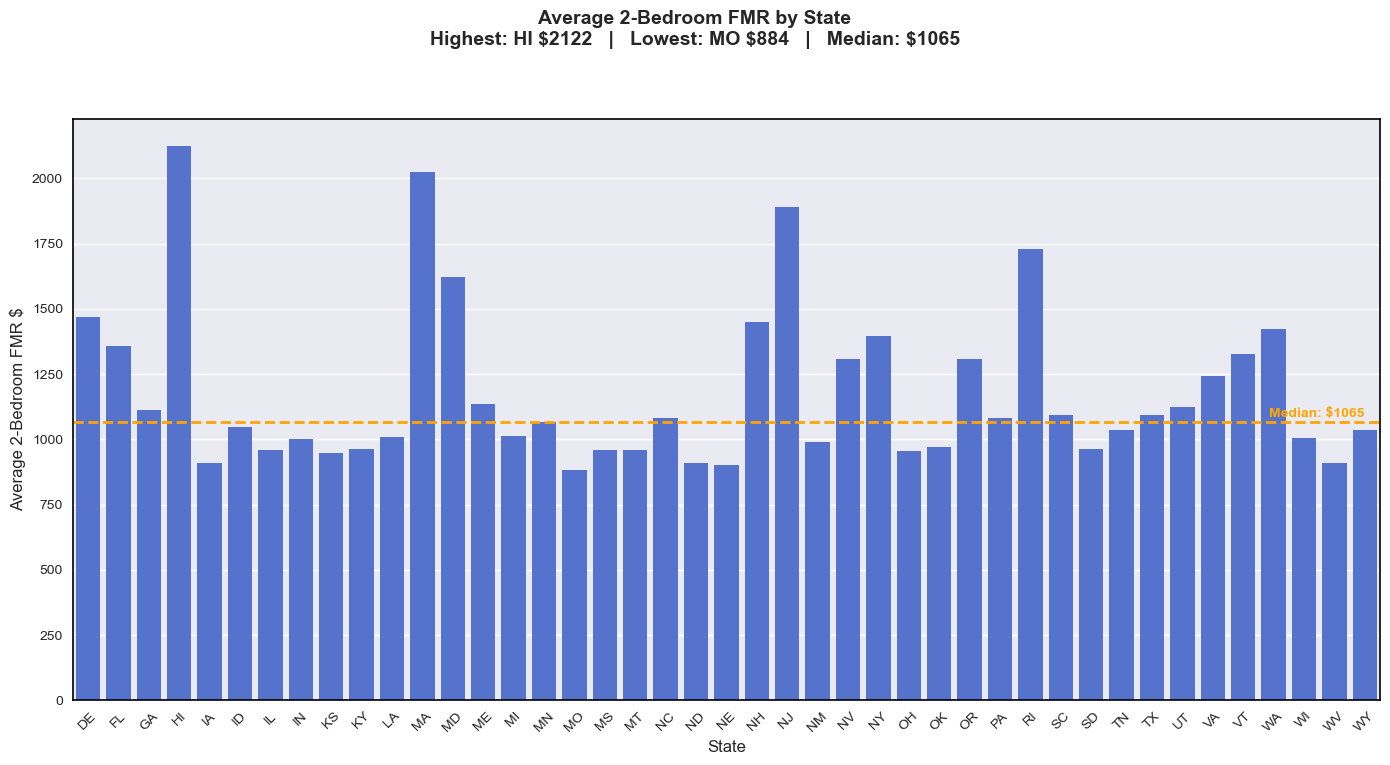

In [221]:
# Calculate state-level averages
state_fmr = merged_ch.groupby('state')['fmr_2'].mean().reset_index()

# Calculate highest, lowest, median
highest = state_fmr.loc[state_fmr['fmr_2'].idxmax()]
lowest = state_fmr.loc[state_fmr['fmr_2'].idxmin()]
median_value = state_fmr['fmr_2'].median()

plt.figure(figsize=(14, 8))

# Title block with all values
plt.suptitle(
    f"Average 2-Bedroom FMR by State\n"
    f"Highest: {highest['state']} ${highest['fmr_2']:.0f}   |   "
    f"Lowest: {lowest['state']} ${lowest['fmr_2']:.0f}   |   "
    f"Median: ${median_value:.0f}",
    fontsize=14,
    fontweight='bold',
    y=0.95
)

# Bar chart
sns.barplot(data=state_fmr, x='state', y='fmr_2', color='royalblue')

plt.xlabel('State')
plt.ylabel('Average 2-Bedroom FMR $')
plt.xticks(rotation=45)

# Label the median line inside the chart
plt.axhline(median_value, color='orange', linestyle='--', linewidth=2)
plt.text(
    x=len(state_fmr) - 1,
    y=median_value + 20,
    s=f"Median: ${median_value:.0f}",
    color='orange',
    fontweight='bold',
    ha='right'
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

<div style="border: 3px solid black; padding: 10px;">

**Key Findings:** Average 2-bedroom Fair Market Rent varies significantly across states, with coastal and northeastern states like HI, CA, MA, and NJ showing the highest rental costs. Southern and midwestern states show the most affordable rental markets. A median reference line is included to provide national context. Data source: Census ACS + HUD FMR.

### Visualization 2: Average 2-Bedroom Fair Market Rent by State
*Chart Type: Filled Map | Data Sources: HUD Fair Market Rent*

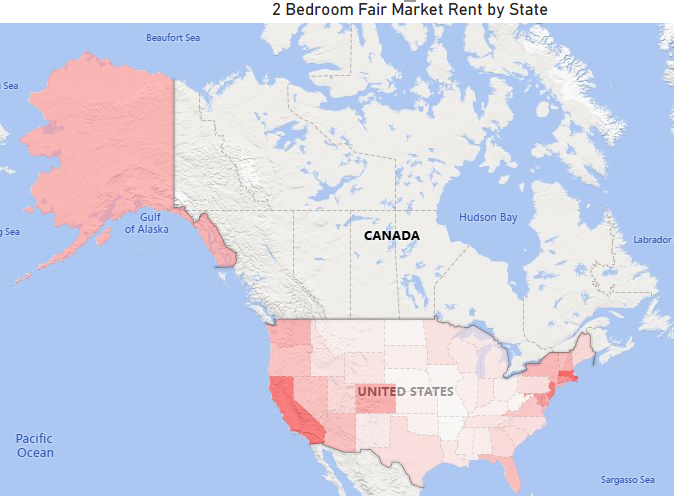

In [222]:
display(Image('Viz2_FMRMap.png'))

<div style="border: 3px solid black; padding: 10px;">

**Key Findings:** Coastal and northeastern states show the highest Fair Market Rent for 2-bedroom units, with CA, NY, MA, and NJ among the most expensive. Southern and midwestern states show significantly lower FMR values. Data source: HUD Fair Market Rent (national coverage).

### Visualization 3: Median Household Income vs. 2-Bedroom FMR by State
*Chart Type: Bubble Chart | Data Sources: Census ACS + HUD FMR*

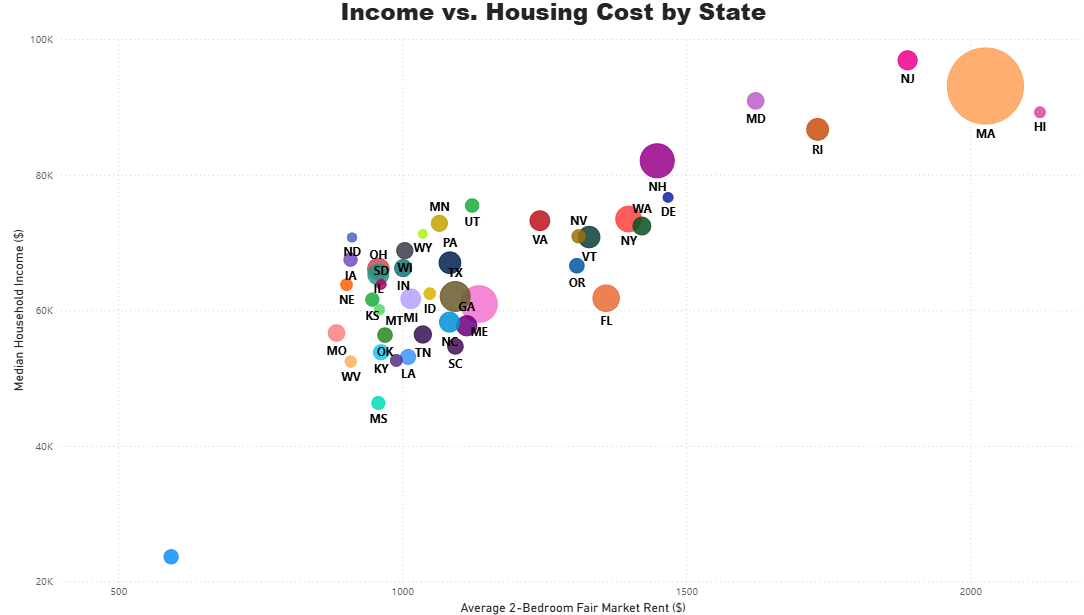

In [223]:
display(Image('Viz3_IncomeVsFMR.png'))

<div style="border: 3px solid black; padding: 10px;">

**Key Findings:** States with higher Median Household Income generally also face higher 2-bedroom Fair Market Rent, indicating that higher earning areas come with higher housing costs. Bubble size represents total population, highlighting that the most populous states tend to cluster in the high income/high rent quadrant. Data source: Census ACS + HUD FMR.

### Visualization 4: Average Fair Market Rent by Bedroom Size
*Chart Type: Clustered Column Chart | Data Sources: HUD Fair Market Rent*

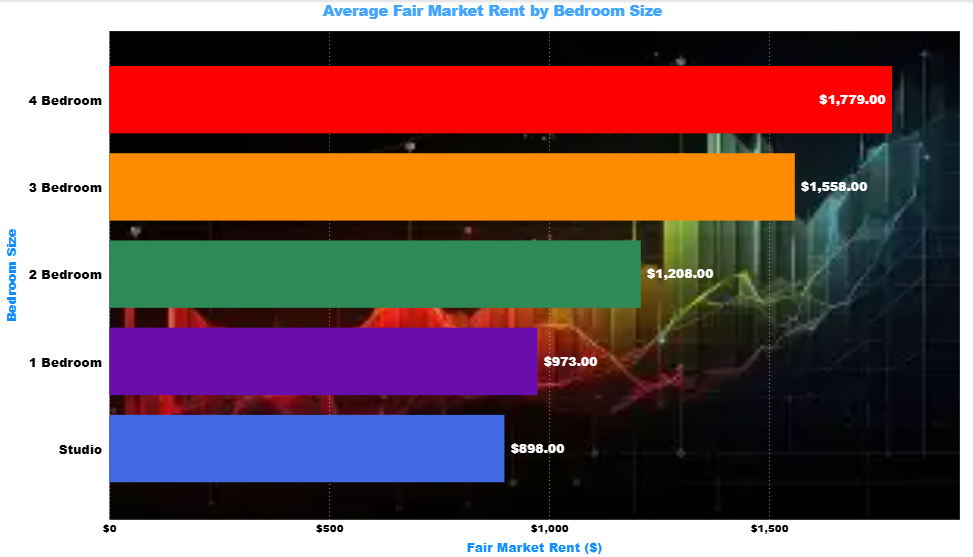

In [224]:
display(Image('Viz4_FMRbyBedroom.png'))

<div style="border: 3px solid black; padding: 10px;">

**Key Findings:** Average Fair Market Rent increases steadily with each additional bedroom, rising from approximately \\$800 for a studio to just under \\$1,800 for a 4-bedroom unit nationally. This trend highlights the significant cost burden larger families face in the rental market. Data source: HUD Fair Market Rent (national coverage).

### Visualization 5: Walk Score vs. Median Household Income by State
*Chart Type: Line & Clustered Column Chart | Data Sources: Census ACS + HUD FMR + Walk Score*

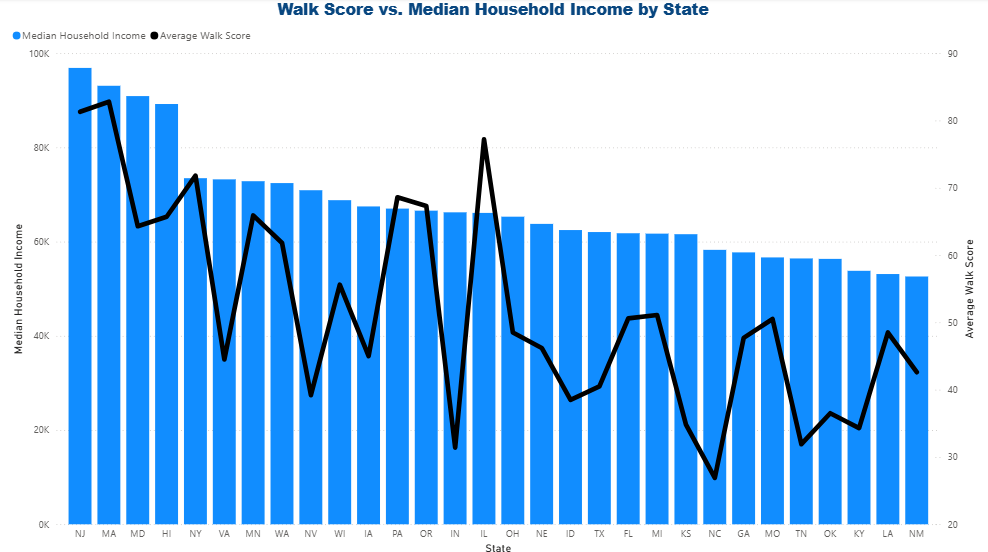

In [225]:
display(Image('Viz5_WSvsMHI.png'))

<div style="border: 3px solid black; padding: 10px;">
    
**Key Findings:** States with higher average Walk Scores tend to have higher Median Household Incomes, suggesting a positive relationship between walkability and economic prosperity, though there are more than a couple of occurrences where that is not the case as there are lulls well below the income level in approximately 8 states (MD, VA, NV, IA, **IN**, ID, NC, and TN) and 3 where the walk score exceeds income (PA, OR, and **IL**). Northeastern states like MA, NY, and NJ lead in both metrics. Data source: Census ACS + HUD FMR + Walk Score (36 states with Walk Score coverage).

### Visualization 6: Quality of Life Index by State
*Chart Type: Clustered Column Chart | Data Sources: Census ACS + HUD FMR + Walk Score*

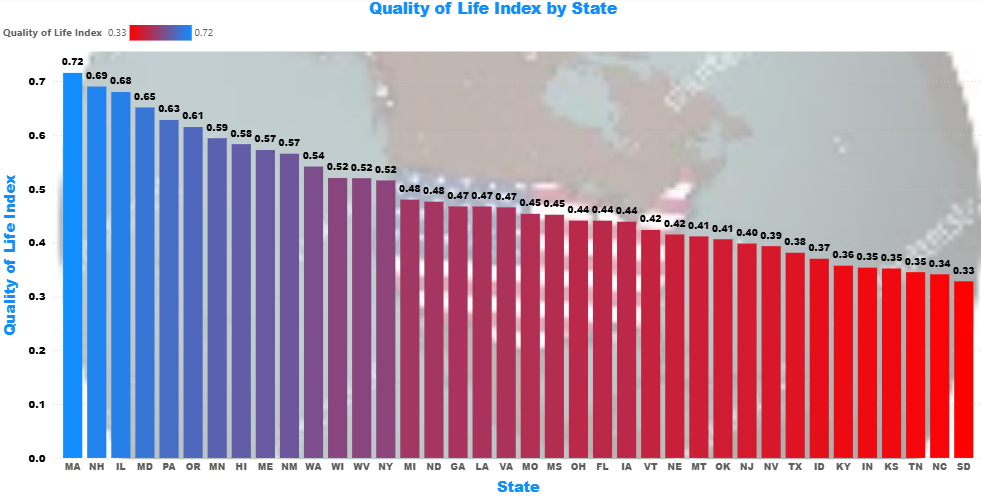

In [226]:
display(Image('Viz6_QoLindex.png'))

<div style="border: 3px solid black; padding: 10px;">

**Key Findings:** Northeastern states consistently score highest on the composite Quality of Life Index, driven by strong walkability, transit access, and higher incomes relative to housing costs. Southern and rural states score lower, reflecting limited transportation infrastructure and lower income levels. Data source: Census ACS + HUD FMR + Walk Score (2,309 counties with complete data).

## Project Summary and Ethical Implications

### Summary

This milestone integrated three distinct datasets: HUD Fair Market Rent, Walk Score City Rankings, and U.S. Census ACS 5-Year Estimates, into a unified SQLite database and produced six visualizations exploring how transportation access and living costs relate to quality of life across U.S. counties. The primary technical challenge was reconciling geographic identifiers across datasets that operate at different levels of granularity: HUD data is published at the sub-county area level, Walk Score data is published at the city level, and Census data is published at the county level. This required a FIPS-based inner join for Census and HUD data, and a state-level aggregation strategy for Walk Score data. A composite Quality of Life Index was developed using Min-Max scaled, weighted components to directly address the project topic.

---

### Data Transformation Summary

| Dataset | Transformation | Details | Count |
|---|---|---|---|
| HUD FMR | Column header standardization | Converted to snake_case | 0 changes needed |
| HUD FMR | County name normalization | Title case applied | 0 changes needed |
| HUD FMR | Duplicate removal | No duplicates found | 0 removed |
| HUD FMR | Rent columns to numeric | Stripped $ and commas | 0 conversions needed |
| HUD FMR | Outlier identification | IQR method on fmr_2 | 213 outliers flagged |
| Walk Score | Column header standardization | Converted to snake_case | 6 headers renamed |
| Walk Score | UTF-8 encoding fix | Corrected garbled city names | 2 names corrected |
| Walk Score | Numeric conversion | Scores and population | 130 values coerced |
| Walk Score | Canadian city identification | Added country column | 22 cities flagged |
| Walk Score | Missing score flagging | Any null score flagged | 7 rows flagged |
| Walk Score | Duplicate removal | No duplicates found | 0 removed |
| Census ACS | Column renaming | API codes → readable names | 9 columns renamed |
| Census ACS | Numeric conversion | 7 fields converted | 22,554 values coerced |
| Census ACS | Invalid income removal | Values <= 0 set to NaN | Per run |
| Census ACS | County name cleaning | Removed County/Parish suffix | 3,063 names updated |
| Census ACS | State abbreviation mapping | Full name → 2-letter code | 50 states mapped |
| Census ACS | FIPS code padding | Zero-padded to standard length | All rows updated |
| Census ACS | Education percentage | Calculated edu_pct field | 3,143 rows updated |
| Census ACS | Duplicate removal | Checked by FIPS | 0 removed |
| Merged | Census + HUD join | FIPS inner join | 4,304 rows produced |
| Merged | Walk Score join | State-level left join | 4,276 rows after dedup |
| Merged | QoL Index calculation | Min-Max scaled composite | 2,309 valid scores |

---

### Ethical Implications

**What changes were made to the data?**
All transformations were limited to standardization, type conversion, and derived field creation. No records were deleted based on value judgments. Outliers in HUD FMR data were flagged but retained. Invalid income values (<=0) were set to NaN rather than imputed to avoid introducing bias. The QoL Index weights reflect deliberate assumptions about what contributes to quality of life and should be interpreted as one possible model rather than a definitive measure.

**Are there any legal or regulatory guidelines for your data or project topic?**
All three data sources are publicly available and free to use. The U.S. Census Bureau ACS data is published under Title 13 of the U.S. Code, which prohibits the release of data that could identify individuals, the county-level aggregates used here are compliant. HUD Fair Market Rent data is published under the Housing Act and is intended for public use in housing policy research. Walk Score data was scraped from a publicly accessible HTML table; commercial use of Walk Score data may require licensing, but academic use is generally permitted.

**What risks could be created based on the transformations done?**
The state-level aggregation of Walk Score data introduces geographic smoothing; a county in a rural state receives the same walk score as a county in a major city within that state. This could overstate walkability for rural counties and understate it for urban ones. The FIPS inner join excludes 318 Census counties and several states, including California, from the merged dataset, which could bias state-level conclusions toward states that are better represented in the HUD data.

**Did you make any assumptions in cleaning and transforming the data?**
Several assumptions were made: (1) HUD records ending in 99999 are metro-area rollup rows and not real counties; (2) Walk Score data aggregated at the state level is a reasonable proxy for county-level transportation access; (3) the QoL Index weights (Income 25%, Walk Score 20%, Transit 20%, FMR 15%, Poverty 10%, Education 10%) reflect a reasonable balance of quality of life factors; (4) ACS 5-Year estimates, while multi-year averages, are sufficiently current for this analysis.

**How was your data sourced and verified for credibility?**
Census ACS data was retrieved directly from the official Census Bureau API, ensuring authenticity. HUD FMR data was sourced from the official HUD flat file published annually by the U.S. Department of Housing and Urban Development. Walk Score data was scraped directly from the Walk Score website. All three sources are widely used in academic, government, and industry research and are considered authoritative for their respective domains.

**Was your data acquired in an ethical way?**
Yes. All three datasets are publicly available and were accessed through official channels. No personally identifiable information was used at any stage. The Census API does not require authentication, ensuring reproducibility without credential exposure. Walk Score data was scraped from a publicly accessible page consistent with general web scraping norms for academic use.

**How would you mitigate any of the ethical implications you have identified?**
The geographic smoothing introduced by state-level Walk Score aggregation could be mitigated in future work by obtaining city-to-county crosswalk data to enable more precise joins. The missing California and other states from the FIPS join could be addressed by supplementing with alternative HUD county crosswalk files. The QoL Index weights should be treated as a starting point and validated against established quality of life indices such as the CDC's Social Vulnerability Index or the UN Human Development Index before drawing policy conclusions.